# Convergence of the normalised OM dissimilarity

Section 5.1 of the paper: Figure 1, and Figures 7 and 8 of the appendix.

Numerical illustration of Proposition 2.3, $\hat\gamma_n = d_{\mathrm{OM}}(X_{1:n}, Y_{1:n})/n
\to \gamma(P,Q)$ almost surely with a limit that does not depend on the initial laws, together
with the two bounds of Proposition 2.8,
$W_{\bar d}(\pi_P,\pi_Q) \le \gamma(P,Q) \le \pi_P^\top S \pi_Q$.

**Design.** $\Sigma = \{0,\dots,4\}$ and the rows of two transition matrices $P, Q$ are drawn
i.i.d. from a Dirichlet distribution with concentration $\alpha = 0.25$ — first draw, no
selection of the pair. Two configurations, each with $R = 30$ independent replicates: a *within*
configuration, where $X$ and $Y$ are independent with the same kernel $P$, so that $\hat\gamma_n$
estimates $\gamma(P,P)$, and a *between* configuration, where $X \sim P$ and $Y \sim Q$.

Each of the $120$ trajectories starts from the Dirac mass at a state drawn uniformly on $\Sigma$,
independently across trajectories: this is the general setting of the proposition, and the least
favourable one, a diffuse initial law being already closer to the stationary law. The spread of
the curves at small $n$ therefore includes the transient due to the initial condition, and its
disappearance is what the second step of the proof asserts.

$\hat\gamma_n$ is evaluated at $24$ log-spaced horizons between $n = 10$ and $n = 10^4$, along
**nested prefixes of the same two trajectories**, so each thin curve is a sample path of
$\hat\gamma_n$ rather than a sequence of independent draws.

The main figure uses the classical sequence-analysis default cost scheme, $c_{\mathrm{sub}}
\equiv 2$ off the diagonal and $\delta \equiv 1$. The appendix figures use a transition-rate
(TRATE) scheme, $c_{\mathrm{sub}} = 2 - \hat P - \hat P^\top$ with $\hat P$ estimated on a pilot
sample independent of the sequences entering $\hat\gamma_n$, and a random symmetric scheme with
$c_{\mathrm{sub}} \sim \mathcal U[1.2, 2]$. The three schemes are applied to the same $120$
trajectories, simulated once, so the three figures are directly comparable.

**Figures.** `Figures/Convergence/gamma_convergence_constant` is Figure 1, and
`gamma_convergence_trate`, `gamma_convergence_random` are Figures 7 and 8.


In [1]:
%load_ext autoreload
%autoreload 2

import time

import numpy as np
import matplotlib.pyplot as plt

from figures import PAPER_STYLE, save
from generators import (sample_chain_order1, sample_markov_model, spectral_gap,
                        stationary_distribution_markov)
from om import (check_assumption_metric, cost_scheme, gamma_hat_paths,
                product_upper_bound, wasserstein_lower_bound)

## Setup: chains and trajectories

The two kernels, their stationary laws, the horizon grid, and the $120$ trajectories, drawn once
and reused by the three cost schemes below. The pilot sample for the TRATE costs is drawn here
too, and is independent of them.


In [ ]:
D_STATES  = 5        # alphabet size
ALPHA_DIR = 0.25     # Dirichlet concentration of the transition rows
N_MAX     = 10_000   # largest horizon
N_GRID    = 24       # points of the logarithmic grid
R_REP     = 30       # replicates per configuration
SEED      = 20260802

rng = np.random.default_rng(SEED)

P = sample_markov_model(D_STATES, 1, ALPHA_DIR, rng)["transitions"]
Q = sample_markov_model(D_STATES, 1, ALPHA_DIR, rng)["transitions"]
pi_P = stationary_distribution_markov(P)
pi_Q = stationary_distribution_markov(Q)

grid = np.unique(np.round(np.geomspace(10, N_MAX, N_GRID)).astype(np.int64))


def draw(kernel):
    """R_REP trajectories of `kernel`, each from its own initial law.

    Replicate r starts from the Dirac law at a state drawn uniformly on Sigma, so no two
    replicates share an initial condition. This is the general setting of Proposition 2.3,
    which allows arbitrary initial laws: since any initial law is a mixture of Diracs, the
    extreme points are the informative case, and they are also the least favourable one --
    a diffuse initial law would already be closer to the stationary law.
    """
    return np.stack([sample_chain_order1(kernel, N_MAX, rng, init=int(a))
                     for a in rng.integers(D_STATES, size=R_REP)])


t0 = time.time()
traj = {
    "within":  (draw(P), draw(P)),
    "between": (draw(P), draw(Q)),
}
# pilot sample, independent of the trajectories above, used to estimate the TRATE costs
pilot_sequences = [sample_chain_order1(P, 5000, rng), sample_chain_order1(Q, 5000, rng)]

print(f"simulation: {time.time() - t0:.1f}s")
print("pi_P =", np.round(pi_P, 3), " spectral gap of P =", round(spectral_gap(P), 3))
print("pi_Q =", np.round(pi_Q, 3), " spectral gap of Q =", round(spectral_gap(Q), 3))
print("grid =", grid)

simulation: 1.2s
pi_P = [0.179 0.153 0.196 0.224 0.247]  spectral gap of P = 0.512
pi_Q = [0.181 0.169 0.111 0.223 0.316]  spectral gap of Q = 0.513
grid = [   10    14    18    25    33    45    61    82   111   149   202   272
   367   496   670   905  1222  1650  2228  3008  4062  5484  7406 10000]


## Sample paths of $\hat\gamma_n$

`run_cost_scheme` checks Assumption 1 for the scheme, computes the paths and the two bounds;
`plot_gamma_convergence` draws one panel: one thin line per replicate, the mean over replicates
on top, and the bounds as horizontal references.


In [3]:
COL_IN, COL_OUT = "#1b6ca8", "#c0392b"


def run_cost_scheme(name, S, delta, verbose=True):
    """Check Assumption 1, then compute the sample paths and the bounds for this scheme."""
    checks = check_assumption_metric(S, delta)
    if verbose:
        print(f"[{name}] Assumption 1:")
        for k, v in checks.items():
            print(f"    {k:30s} {v}")
    t0 = time.time()
    paths = {k: gamma_hat_paths(A, B, grid, S, delta) for k, (A, B) in traj.items()}
    bounds = {
        "within":  (wasserstein_lower_bound(pi_P, pi_P, S), product_upper_bound(pi_P, pi_P, S)),
        "between": (wasserstein_lower_bound(pi_P, pi_Q, S), product_upper_bound(pi_P, pi_Q, S)),
    }
    if verbose:
        print(f"[{name}] OM computations: {time.time() - t0:.1f}s")
        for key in traj:
            lo, hi = bounds[key.split("_")[0]]
            print(f"    {key:20s} LB={lo:.3f}   hat-gamma_{grid[-1]}="
                  f"{paths[key][:, -1].mean():.3f}   UB={hi:.3f}")
    return {"paths": paths, "bounds": bounds, "checks": checks, "S": S, "delta": delta}


def plot_gamma_convergence(res, title, filename=None):
    """Single-panel figure: sample paths of hat-gamma_n, with the bounds of Proposition 2.8.

    The legend sits below the axes: the replicate clouds fill the panel at small n, so any
    in-axes placement would hide part of them.
    """
    paths, bounds = res["paths"], res["bounds"]
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.2, 4.0))
        for key, col, lab in (("within", COL_IN, r"$(P,P)$"), ("between", COL_OUT, r"$(P,Q)$")):
            ax.plot(grid, paths[key].T, color=col, lw=0.6, alpha=0.16)
            ax.plot(grid, paths[key].mean(0), color=col, lw=1.9, label=rf"$\hat\gamma_n$, {lab}")
        _, hi_in = bounds["within"]
        lo_out, hi_out = bounds["between"]
        ax.axhline(hi_in, color=COL_IN, ls=(0, (5, 3)), lw=1.0, label=r"$\pi_P^{T} S\,\pi_P$")
        ax.axhline(lo_out, color=COL_OUT, ls=(0, (1, 2)), lw=1.2,
                   label=r"$W_{\bar{d}}(\pi_P,\pi_Q)$")
        ax.axhline(hi_out, color=COL_OUT, ls=(0, (5, 3)), lw=1.0, label=r"$\pi_P^{T} S\,\pi_Q$")

        ax.set_xscale("log")
        ax.set_xlabel(r"$n$")
        ax.set_ylabel(r"$\hat\gamma_n = d_{\mathrm{OM}}(X_{1:n},Y_{1:n})\,/\,n$")
        ax.set_ylim(bottom=0.0)
        ax.set_title(title, fontsize=10)
        # three curve entries in the left column, the three bounds in the right one
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2,
                  handlelength=2.6, columnspacing=1.8, borderaxespad=0.0)
        fig.subplots_adjust(left=0.155, right=0.98, top=0.92, bottom=0.33)
        if filename is not None:
            save(fig, "Figures/Convergence", filename)
        plt.show()
    return fig

### Main figure: constant costs

[constant] Assumption 1:
    (i) delta > 0                  True
    (ii) symmetry                  True
    (iii) triangle inequality      True
    (iv) c_sub <= delta + delta    True
    (v) delta <= c_sub + delta     True
    (vi) c_sub > 0 off-diagonal    True
    zero diagonal                  True
    M = max c_sub                  2.0
[constant] OM computations: 20.4s
    within               LB=0.000   hat-gamma_10000=0.622   UB=1.589
    between              LB=0.173   hat-gamma_10000=0.798   UB=1.583
figure written to Figures\Convergence\gamma_convergence_constant.pdf


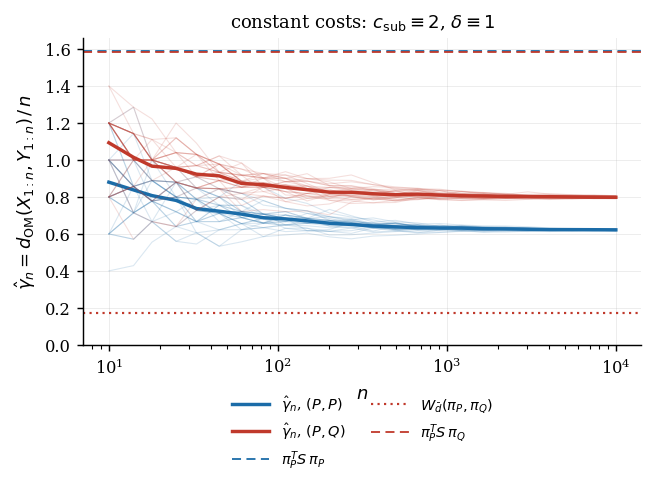

In [4]:
S_const, delta_const = cost_scheme("constant", D_STATES, sub=2.0, indel=1.0)
res_const = run_cost_scheme("constant", S_const, delta_const)
_ = plot_gamma_convergence(
    res_const,
    title="constant costs: $c_{\\mathrm{sub}}\\equiv 2$, $\\delta\\equiv 1$",
    filename="gamma_convergence_constant",
)

### Appendix: TRATE and random costs, same trajectories

[trate] Assumption 1:
    (i) delta > 0                  True
    (ii) symmetry                  True
    (iii) triangle inequality      True
    (iv) c_sub <= delta + delta    True
    (v) delta <= c_sub + delta     True
    (vi) c_sub > 0 off-diagonal    True
    zero diagonal                  True
    M = max c_sub                  1.9158612488651383
[trate] OM computations: 16.3s
    within               LB=0.000   hat-gamma_10000=0.567   UB=1.261
    between              LB=0.139   hat-gamma_10000=0.712   UB=1.255
figure written to Figures\Convergence\gamma_convergence_trate.pdf


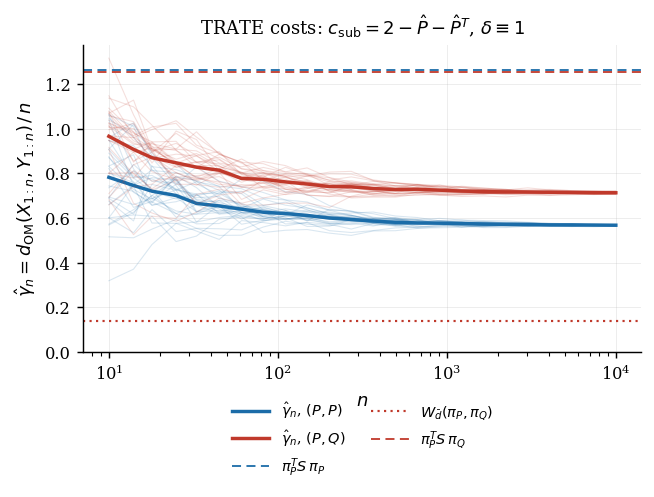


TRATE cost matrix:
 [[0.    1.882 1.462 1.48  1.468]
 [1.882 0.    1.152 1.589 1.764]
 [1.462 1.152 0.    1.916 1.722]
 [1.48  1.589 1.916 0.    1.43 ]
 [1.468 1.764 1.722 1.43  0.   ]]


In [5]:
S_trate, delta_trate = cost_scheme("trate", D_STATES, pilot_sequences=pilot_sequences, indel=1.0)
res_trate = run_cost_scheme("trate", S_trate, delta_trate)
_ = plot_gamma_convergence(
    res_trate,
    title="TRATE costs: $c_{\\mathrm{sub}}=2-\\hat{P}-\\hat{P}^{T}$, $\\delta\\equiv 1$",
    filename="gamma_convergence_trate",
)
print("\nTRATE cost matrix:\n", np.round(S_trate, 3))

In [ ]:
S_rand, delta_rand = cost_scheme("random", D_STATES, rng=np.random.default_rng(SEED + 1),
                                 low=1.2, high=2.0, indel=1.0)
res_rand = run_cost_scheme("random", S_rand, delta_rand)
_ = plot_gamma_convergence(
    res_rand,
    title="random costs: $c_{\\mathrm{sub}}\\sim\\mathcal{U}[1.2,2]$, $\\delta\\equiv 1$",
    filename="gamma_convergence_random",
)

[random] Assumption 1:
    (i) delta > 0                  True
    (ii) symmetry                  True
    (iii) triangle inequality      True
    (iv) c_sub <= delta + delta    True
    (v) delta <= c_sub + delta     True
    (vi) c_sub > 0 off-diagonal    True
    zero diagonal                  True
    M = max c_sub                  1.6801890761546594
[random] OM computations: 17.7s
    within               LB=0.000   hat-gamma_10000=0.557   UB=1.198
    between              LB=0.132   hat-gamma_10000=0.701   UB=1.192
